In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')
import importlib
import main_functions
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

importlib.reload(main_functions) 
from main_functions import *

### Применим методы машинного обучения, чтобы улучшить стратегию, которую мы отобрали ранее. Мы будем использовать стратегии под номером 1.
1) Бычье поглощение - 1 h, N=4

In [26]:
rosneft = pd.read_csv(r'C:\Users\user\Desktop\Проект 1 года обучения\Проверка эффективности паттернов\Данные для анализа\ROSN.txt')
with open(r'C:\Users\user\Desktop\Проект 1 года обучения\Повышение эффективности с помощью ML\Результаты паттернов\results_strategies_rosneft.pkl', 'rb') as file:
    rosneft_result = pickle.load(file)
display(rosneft_result.head(3))
display(rosneft.head(2))

,ticker,strategy name,period,N,count of trades,profit factor,total percent return,R2,win_rate,mean profit (%),...,max drawdown (%),capital curve net,capital curve without commission,profit percent net,percent profit without commission,profit factor rank,R2 rank,profit/loss ratio rank,max drawdown rank,best model
0,ROSN,bullish_engulfing_pattern,1h,4,1384,1.229,184.50,0.82,0.50,0.9,...,27.9,time_N 2009-01-12 16:00:00 98190.000000 20...,time_N 2009-01-12 16:00:00 98229.000000 20...,time_N 2009-01-12 16:00:00 -0.01810 2009-01-...,time_N 2009-01-12 16:00:00 -0.01771 2009-01-...,8.0,6.0,7.5,7.0,28.5
1,ROSN,bullish_engulfing_pattern,1h,5,1354,1.176,137.91,0.83,0.50,1.0,...,31.7,time_N 2009-01-12 16:00:00 98628.000000 20...,time_N 2009-01-12 16:00:00 98668.000000 20...,time_N 2009-01-12 16:00:00 -0.01372 2009-01-...,time_N 2009-01-12 16:00:00 -0.01332 2009-01-...,4.0,7.5,6.0,5.0,22.5
2,ROSN,bullish_engulfing_pattern,1h,10,1152,1.218,252.29,0.83,0.51,1.4,...,39.2,time_N 2009-01-12 16:00:00 100533.000000 20...,time_N 2009-01-12 16:00:00 100573.000000 20...,time_N 2009-01-12 16:00:00 0.00533 2009-01-...,time_N 2009-01-12 16:00:00 0.00573 2009-01-...,7.0,7.5,3.0,3.0,20.5


,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>
0,ROSN,1,20090111,103000,114.90,114.90,113.03,113.1,95460
1,ROSN,1,20090111,103100,113.31,113.75,112.04,112.4,89619


### Попробуем улучшить сперва стратегию 1.

In [27]:
def preperation_to_modeling(data, period, func, N, profit):
    """Функция предназначена для подготовки датафрейма к дальнейшему моделированию

    Args:
        data (pd.DataFrame): 1-минутный таймфрейм
        period (object): Передаем период из стратегии
        func (function): Какой паттерн проверяем?
        N (int): Сколько следующих свеч удерживаем паттерн?
        profit (pd.Series): Численные результаты торгов

    Returns:
        Подготовленный датафрейм для использования ml
    """
    data_timeframe = good_dataframe(data, period)
    data_with_pattern = func(shift_features_2_candle(data_timeframe))
    
    # Обрезка
    data_with_pattern.loc[len(data_with_pattern) - 51 : len(data_with_pattern), ['pattern', 'signal']] = 0
    data_filter = filter_min_distance(data_with_pattern, 'signal', N)
    data_filter['signal_N-1'] = data_filter['signal'].shift(-1)
    data_filter.loc[data_filter['signal_N-1'] == 0, 'pattern'] = 0
    data_filter.drop(['signal', 'signal_N-1', 'per', 'ticker', 'strategy'], axis=1, inplace=True)
    data_filter.dropna(inplace=True)
    
    # Соединяем доходности
    result = profit.loc[0, 'profit percent net']
    data_filter = data_filter.set_index('time_N')
    final_data = data_filter.join(result).fillna(0)
    final_data = final_data.reset_index()
    final_data['profit_percent_net'] = final_data['profit_percent_net'].shift(-1)
    return final_data

df = preperation_to_modeling(rosneft, '1h', detection_bullish_engulfing_pattern, 4, rosneft_result)

In [28]:
df

,time_N,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N-1,pattern,profit_percent_net
0,2009-01-11 11:00:00,114.71,114.90,113.99,114.71,113.80,112.04,115.85,114.90,607025,726986.0,2009-01-11 10:00:00,0,0.0
1,2009-01-11 12:00:00,114.00,114.71,114.20,113.99,113.54,113.80,115.29,115.85,319417,607025.0,2009-01-11 11:00:00,0,0.0
2,2009-01-11 13:00:00,114.15,114.00,114.17,114.20,114.00,113.54,114.57,115.29,192269,319417.0,2009-01-11 12:00:00,0,0.0
3,2009-01-11 14:00:00,114.40,114.15,114.15,114.17,114.15,114.00,114.45,114.57,31061,192269.0,2009-01-11 13:00:00,0,0.0
4,2009-01-11 15:00:00,114.27,114.40,113.85,114.15,113.64,114.15,114.27,114.45,180310,31061.0,2009-01-11 14:00:00,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47403,2026-03-31 19:00:00,485.30,482.85,483.30,485.35,481.25,482.70,487.50,488.85,968564,2301124.0,2026-03-31 18:00:00,0,0.0
47404,2026-03-31 20:00:00,483.30,485.30,482.55,483.30,481.10,481.25,483.55,487.50,643442,968564.0,2026-03-31 19:00:00,0,0.0
47405,2026-03-31 21:00:00,482.55,483.30,482.00,482.55,481.95,481.10,483.15,483.55,189905,643442.0,2026-03-31 20:00:00,0,0.0
47406,2026-03-31 22:00:00,481.95,482.55,483.30,482.00,481.90,481.95,483.75,483.15,190075,189905.0,2026-03-31 21:00:00,0,0.0


### Создаем признаки

In [29]:
# Признаки по дате и времени
def data_time_features(data):
    """Функция для создания временных признаков

    Args:
        data (pd.DataFrame): Датафрейм с разметкой данных

    Returns:
       data (pd.DataFrame): Новый датафрейм с временными признаками
    """
    data = data.copy()
    data['time_N'] = pd.to_datetime(data['time_N'])
    data['months_N'] = data['time_N'].dt.month
    data['days_N'] = data['time_N'].dt.day
    data['hours_N'] = data['time_N'].dt.hour
    data.drop('time_N', axis=1, inplace=True)
    
    return data

In [30]:
# Признаки по каждой свече
def data_one_candle_features_1(data):
    """
    Расчет характеристик свечей для ML-моделей.
    
    Признаки для текущей свечи (N) и предыдущей (N-1):
        - has_body_N, has_body_N-1: наличие тела свечи
        - ratio_body_to_all_candle_N: отношение тела к полному диапазону (High-Low)
        - ratio_up_shadow_to_body_N: отношение верхней тени к телу
        - ratio_low_shadow_to_body_N: отношение нижней тени к телу
        - ratio_up_to_low_shadow_N: соотношение верхней и нижней теней
        - has_both_shadows_N: наличие обеих теней
    
    Args:
        data (pd.DataFrame): DataFrame с колонками open_N, high_N, low_N, close_N,
                            open_N-1, high_N-1, low_N-1, close_N-1
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные признаки (NaN заменены на 0)"""
    data = data.copy()
    # Отношение тела свечи ко всей свече
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    # есть ли тело и есть ли свеча
    data['has_body_N'] = (body_N > 0).astype('int')
    data['has_body_N-1'] = (body_N_1 > 0).astype('int')
    data['has_full_candle_N'] = (full_candle_N > 0).astype('int')
    data['has_full_candle_N-1'] = (full_candle_N_1 > 0).astype('int')
    
    data['ratio_body_to_all_candle_N'] = np.where(full_candle_N > 0, body_N / full_candle_N, np.nan)
    data['ratio_body_to_all_candle_N-1'] = np.where(full_candle_N_1 > 0, body_N_1 / full_candle_N_1, np.nan)
    
    # Отношение верхней тени к телу свечи
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    data['ratio_up_shadow_to_body_N'] = np.where(body_N > 0, up_shadow_N / body_N, np.nan)
    data['ratio_up_shadow_to_body_N-1'] = np.where(body_N_1 > 0, up_shadow_N_1 / body_N_1, np.nan)

    # Отношение нижней тени к телу свечи
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    data['ratio_low_shadow_to_body_N'] = np.where(body_N > 0, low_shadow_N / body_N, np.nan)
    data['ratio_low_shadow_to_body_N-1'] = np.where(body_N_1 > 0, low_shadow_N_1 / body_N_1, np.nan)

    # Отношение верхней тени к нижней тени
    data['ratio_up_to_low_shadow_N'] = np.where((low_shadow_N > 0) & (up_shadow_N > 0), up_shadow_N / low_shadow_N, np.nan)
    data['ratio_up_to_low_shadow_N-1'] = np.where((low_shadow_N_1 > 0) & (up_shadow_N_1 > 0), up_shadow_N_1 / low_shadow_N_1, np.nan)

    # Добавляем бинарный признак: есть ли обе тени
    data['has_both_shadows_N'] = ((low_shadow_N > 0) & (up_shadow_N > 0)).astype('int')
    data['has_both_shadows_N-1'] = ((low_shadow_N_1 > 0) & (up_shadow_N_1 > 0)).astype('int')
    
    data = data.fillna(0)

    
    return data

In [31]:
def data_one_candle_features_2(data):
    """Расчет ATR-нормированных признаков свечей.
    
    Признаки (нормированы на ATR):
        - body_ATR_N, body_ATR_N-1: размер тела свечи
        - full_candle_ATR_N, full_candle_ATR_N-1: полный диапазон High-Low
        - up_shadow_ATR_N, up_shadow_ATR_N-1: верхняя тень
        - low_shadow_ATR_N, low_shadow_ATR_N-1: нижняя тень
    
    Args:
        data (pd.DataFrame): DataFrame с колонками open_N, high_N, low_N, close_N,
                            open_N-1, high_N-1, low_N-1, close_N-1
    
    Returns:
        pd.DataFrame: Отфильтрованный DataFrame (удалены строки без ATR) с добавленными признаками"""
    
    data = data.copy()
    def ATR(data, period=14):
        high_low = data['high_N'] - data['low_N']
        high_close_prev = np.abs(data['high_N'] - data['close_N'].shift(1))
        low_close_prev = np.abs(data['low_N'] - data['close_N'].shift(1))
    
        TR = np.maximum(high_low, np.maximum(high_close_prev, low_close_prev))
        ATR = TR.rolling(period).mean()
    
        return ATR
    
    atr = ATR(data).shift(1)
    valid_mask = ~atr.isna()
    data = data[valid_mask]
    atr = atr[valid_mask]
    
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    atr_safe = np.where(atr != 0, atr, 10e-8 )
    
    # Тело свечи / ATR
    data['body_ATR_N'] = body_N / atr_safe
    data['body_ATR_N-1'] = body_N_1 / atr_safe
    
    # Вся свеча / ATR
    data['full_candle_ATR_N'] = full_candle_N / atr_safe
    data['full_candle_ATR_N-1'] = full_candle_N_1 / atr_safe
    
    # Верхняя тень / ATR
    data['up_shadow_ATR_N'] = up_shadow_N / atr_safe
    data['up_shadow_ATR_N-1'] = up_shadow_N_1 / atr_safe
    
    # Нижняя тень / ATR
    data['low_shadow_ATR_N'] = low_shadow_N / atr_safe
    data['low_shadow_ATR_N-1'] = low_shadow_N_1 / atr_safe
    
    return data

In [32]:
def data_two_candles_features(data):
    """
    Расчет межсвечных отношений для двухсвечных паттернов.
    
    Признаки (текущая свеча N к предыдущей N-1):
        - ratio_body_N_to_N-1: отношение размера тела
        - ratio_full_candle_N_to_N-1: отношение полного диапазона
        - ratio_up_shadow_N_to_N-1: отношение верхней тени
        - ratio_low_shadow_N_to_N-1: отношение нижней тени
    
    Бинарные признаки:
        - has_up_shadow_N, has_up_shadow_N-1: наличие верхней тени
        - has_low_shadow_N, has_low_shadow_N-1: наличие нижней тени
    
    Args:
        data (pd.DataFrame): DataFrame с колонками open_N, high_N, low_N, close_N,
                            open_N-1, high_N-1, low_N-1, close_N-1
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные признаки (NaN заменены на 0)
    """
    data = data.copy()
    
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    
    data['ratio_body_N_to_N-1'] = np.where(body_N_1 > 0, body_N / body_N_1, np.nan)
    data['ratio_full_candle_N_to_N-1'] = np.where(full_candle_N_1 > 0, full_candle_N / full_candle_N_1, np.nan)
    data['ratio_up_shadow_N_to_N-1'] = np.where(up_shadow_N_1 > 0, up_shadow_N / up_shadow_N_1, np.nan)
    data['ratio_low_shadow_N_to_N-1'] = np.where(low_shadow_N_1 > 0, low_shadow_N / low_shadow_N_1, np.nan)
    
    # Бинарные признаки
    data['has_up_shadow_N'] = (up_shadow_N > 0).astype('int')
    data['has_low_shadow_N'] = (low_shadow_N > 0).astype('int')
    data['has_up_shadow_N-1'] = (up_shadow_N_1 > 0).astype('int')
    data['has_low_shadow_N-1'] = (low_shadow_N_1 > 0).astype('int')
    
    data = data.fillna(0)
    return data
     

In [33]:
def indicators(data):
    """
    Расчет технических индикаторов для ML-моделей.
    
    Индикаторы для свечей N и N-1:
        - RSI (14): индекс относительной силы
        - SMA (5,10,20,30,50,100,150,200): процентное отклонение цены от скользящей средней
        - Volume Z-score: нормированный объем (63-период)
        - Стохастик (14,3): %K и %D линии
    
    Args:
        data (pd.DataFrame): DataFrame с колонками close_N, close_N-1, high_N, high_N-1,
                            low_N, low_N-1, volume_N, volume_N-1
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные индикаторы
    """
    data = data.copy()
    
    # RSI
    def rsi(prices, n=14):
        deltas = np.diff(prices)
        gains = np.where(deltas > 0, deltas, 0)
        loss = np.where(deltas < 0, -deltas, 0)
        
        avg_gain = np.mean(gains[:n])
        avg_loss = np.mean(loss[:n])
        
        rsi = np.zeros_like(prices)
        rsi[:n] = np.nan
        
        for i in range(n, len(prices)):
            avg_gain = (avg_gain * (n - 1) + gains[i-1]) / n
            avg_loss = (avg_loss * (n - 1) + loss[i-1]) / n
            if avg_loss == 0:
                rsi[i] = 100
            else:
                rs = avg_gain / avg_loss
                rsi[i] = 100 - 100 / (1 + rs)
        return rsi

    data['RSI_N'] = rsi(data['close_N'], 14)
    data['RSI_N-1'] = data['RSI_N'].shift(1)
    
    # SMA
    sma_periods = [5, 10, 20, 30, 50, 100, 150, 200]
    for i in sma_periods:
        # Для N: используем данные до N-1
        sma_N = data['close_N'].shift(1).rolling(i).mean()
        # Для N-1: данные доступны
        sma_N_1 = data['close_N-1'].rolling(i).mean()
        
        data[f'diff_SMA_{i}_N'] = ((data['close_N'] - sma_N) / (sma_N + 1e-8)) * 100
        data[f'diff_SMA_{i}_N-1'] = ((data['close_N-1'] - sma_N_1) / (sma_N_1 + 1e-8)) * 100
    
    # Volume
    def volume(data, column):
        data = data.copy()
        # Для текущего значения volume_N используем данные до N-1
        shifted = data[column].shift(1)
        volume_ma = shifted.rolling(63).mean()
        volume_std = shifted.rolling(63).std()
        data[f'{column}_Z'] = (data[column] - volume_ma) / (volume_std + 1e-8)
        return data
    
    data = volume(data, 'volume_N')
    data = volume(data, 'volume_N-1')
    
    # Стохастик
    def stochastic_oscillator(high, low, close, k_period=14, d_period=3):
        low_min = low.rolling(window=k_period).min()
        high_max = high.rolling(window=k_period).max()
        k = 100 * (close - low_min) / (high_max - low_min + 1e-8)
        d = k.rolling(window=d_period).mean()
        return k, d
    
    stoch_k_N, stoch_d_N = stochastic_oscillator(
        data['high_N'].shift(1),
        data['low_N'].shift(1),
        data['close_N'].shift(1))
    
    data['STOCH_K_N'] = stoch_k_N
    data['STOCH_D_N'] = stoch_d_N
    
    stoch_k_N1, stoch_d_N1 = stochastic_oscillator(
        data['high_N-1'],
        data['low_N-1'],
        data['close_N-1'])
    
    data['STOCH_K_N-1'] = stoch_k_N1
    data['STOCH_D_N-1'] = stoch_d_N1
    return data

In [34]:
def create_lag_indicators(data):
    """Создание лаговых признаков на основе исторических данных (до N-1 свечи).
    
    Признаки для N-1 и N (лаг на 1 период):
        - Change_{1,3,5,10,15,20}_N-1: процентное изменение цены за i периодов
        - up_days_{i}_N-1: количество растущих дней за i периодов
        - down_days_{i}_N-1: количество падающих дней за i периодов
        - up_down_ratio_{i}_N-1: отношение растущих дней к падающим
    
    Args:
        data (pd.DataFrame): DataFrame с колонкой close_N-1
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные лаговые признаки"""
    data = data.copy()
    periods = [1, 3, 5, 10, 15, 20]
    close_base = data['close_N-1']
    daily_change = close_base.pct_change()
    
    for i in periods:
        # Изменения
        data[f'Change_{i}_N-1'] = (close_base / close_base.shift(i) - 1) * 100
        
        # up/down дни
        up_rolling = (daily_change > 0).rolling(i).sum()
        down_rolling = (daily_change < 0).rolling(i).sum()
        
        data[f'up_days_{i}_N-1'] = up_rolling
        data[f'down_days_{i}_N-1'] = down_rolling
        data[f'up_down_ratio_{i}_N-1'] = np.where(down_rolling > 0, up_rolling / down_rolling, 0)
    
    for i in periods:
        for suffix in ['Change', 'up_days', 'down_days', 'up_down_ratio']:
            col = f'{suffix}_{i}_N-1'
            if col in data.columns:
                data[f'{suffix}_{i}_N'] = data[col].shift(1)
    return data

In [35]:
def add_features(data):
    """
    Основная функция конструирования признаков для ML-модели.
    
    Этапы:
        1. Временные признаки (data_time_features)
        2. Характеристики одиночных свечей (data_one_candle_features_1)
        3. ATR-нормированные признаки (data_one_candle_features_2)
        4. Межсвечные отношения (data_two_candles_features)
        5. Технические индикаторы (indicators)
        6. Лаговые признаки (create_lag_indicators)
    
    После создания признаков:
        - Фильтрация только сигнальных свечей (pattern == 1)
        - Удаление исходных OHLCV колонок
        - Масштабирование profit_percent_net (*100)
        - Удаление строк с NaN
    
    Args:
        data (pd.DataFrame): DataFrame с OHLCV данными и колонкой pattern
    
    Returns:
        pd.DataFrame: Подготовленный DataFrame с признаками для обучения
    """
    data = data.copy()
    # Добавляем признаки
    data = data_time_features(data)
    data = data_one_candle_features_1(data)
    data = data_one_candle_features_2(data)
    data = data_two_candles_features(data)
    data = indicators(data)
    data = create_lag_indicators(data)
    
    # Финальная подготовка
    data = data[data['pattern'] == 1]
    data.drop(['open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N', 'low_N-1',
       'high_N', 'high_N-1', 'time_N-1', 'volume_N', 'volume_N-1', 'pattern'], axis=1, inplace=True)
    data['profit_percent_net'] = data['profit_percent_net'] * 100
    data.dropna(inplace=True)
    return data
    

In [36]:
df = add_features(df)
df.head(3)

,profit_percent_net,months_N,days_N,hours_N,has_body_N,has_body_N-1,has_full_candle_N,has_full_candle_N-1,ratio_body_to_all_candle_N,ratio_body_to_all_candle_N-1,...,down_days_10_N,up_down_ratio_10_N,Change_15_N,up_days_15_N,down_days_15_N,up_down_ratio_15_N,Change_20_N,up_days_20_N,down_days_20_N,up_down_ratio_20_N
262,0.794,2,19,12,1,1,1,1,0.576000,0.090909,...,5.0,1.000000,-7.178645,6.0,9.0,0.666667,-10.095465,8.0,12.0,0.666667
289,-0.995,2,25,12,1,1,1,1,0.357143,0.132450,...,4.0,1.500000,3.377897,8.0,7.0,1.142857,-0.761465,9.0,11.0,0.818182
297,2.158,2,26,11,1,1,1,1,0.971204,0.697674,...,6.0,0.666667,4.266495,8.0,7.0,1.142857,1.388889,10.0,10.0,1.000000


## Отбираем признаки

In [37]:
def clean_features(data, threshold = 0.95):
    """
    Очистка признаков от константных и высококоррелирующих.
    
    Удаляет:
        - признаки с единственным уникальным значением (константные)
        - при корреляции между признаками >= threshold оставляет тот,
          который сильнее коррелирует с целевой переменной profit_percent_net
    
    Args:
        data (pd.DataFrame): DataFrame с признаками и целевой колонкой 'profit_percent_net'
        threshold (float, optional): Порог корреляции для удаления. Defaults to 0.95
    
    Returns:
        pd.DataFrame: Очищенный DataFrame
    """
    
    data = data.copy()
    target_column = 'profit_percent_net'
    n_col = data.shape[1]
    print(f'Признаков до удаления: {n_col}')
    
    # Удаляем константные признаки
    delete_list = [col for col in data.columns if data[col].nunique() == 1]
    data.drop(delete_list, axis=1, inplace=True)
    print(f'Константные признаки:', delete_list)

    # Обновляем список признаков после удаления константных
    features_list = [col for col in data.columns if col != target_column]

    # Занимаемся мультиколлинеарностью
    del_set = set()
    for i, col1 in enumerate(features_list):
        for j in range(i+1, len(features_list)):
            col2 = features_list[j]
            corr_between = np.abs(data[col1].corr(data[col2]))
            corr1 = np.abs(data[target_column].corr(data[col1]))
            corr2 = np.abs(data[target_column].corr(data[col2]))
            if corr_between >= threshold:
                
                if corr1 >= corr2:
                    del_set.add(col2)
                else:
                    del_set.add(col1)
    data.drop(list(del_set), axis=1, inplace=True)
    print(f'Признаки с мультиколлинеарностью > {threshold}:', *list(del_set))
    print(f'Признаков после удаления: {n_col - len(del_set) - len(delete_list)}')       
    return data

df_ml =  clean_features(df)
df_ml

Признаков до удаления: 106
Константные признаки: ['has_body_N', 'has_body_N-1', 'has_full_candle_N', 'has_full_candle_N-1', 'up_down_ratio_1_N-1', 'up_down_ratio_1_N']
Признаки с мультиколлинеарностью > 0.95: STOCH_K_N-1 Change_20_N RSI_N-1 down_days_5_N-1 diff_SMA_200_N down_days_3_N-1 up_days_20_N diff_SMA_30_N-1 down_days_1_N diff_SMA_50_N up_down_ratio_20_N-1 STOCH_D_N-1 diff_SMA_150_N-1 diff_SMA_100_N down_days_20_N-1 diff_SMA_150_N down_days_15_N-1 down_days_3_N up_days_15_N-1 down_days_15_N down_days_10_N-1 down_days_5_N STOCH_K_N down_days_10_N
Признаков после удаления: 76


,profit_percent_net,months_N,days_N,hours_N,ratio_body_to_all_candle_N,ratio_body_to_all_candle_N-1,ratio_up_shadow_to_body_N,ratio_up_shadow_to_body_N-1,ratio_low_shadow_to_body_N,ratio_low_shadow_to_body_N-1,...,up_days_5_N,up_down_ratio_5_N,Change_10_N,up_days_10_N,up_down_ratio_10_N,Change_15_N,up_days_15_N,up_down_ratio_15_N,down_days_20_N,up_down_ratio_20_N
262,0.794,2,19,12,0.576000,0.090909,0.083333,4.636364,0.652778,5.363636,...,3.0,1.500000,-0.220731,5.0,1.000000,-7.178645,6.0,0.666667,12.0,0.666667
289,-0.995,2,25,12,0.357143,0.132450,0.740000,2.700000,1.060000,3.850000,...,3.0,1.500000,3.102222,6.0,1.500000,3.377897,8.0,1.142857,11.0,0.818182
297,2.158,2,26,11,0.971204,0.697674,0.026954,0.333333,0.002695,0.100000,...,2.0,0.666667,-0.123577,4.0,0.666667,4.266495,8.0,1.142857,10.0,1.000000
328,5.775,3,3,15,0.793443,0.543103,0.243802,0.465608,0.016529,0.375661,...,2.0,0.666667,-0.580682,4.0,0.666667,-0.197044,7.0,0.875000,12.0,0.666667
334,2.179,3,4,12,0.659794,0.381526,0.171875,1.052632,0.343750,0.568421,...,5.0,0.000000,7.268191,7.0,2.333333,6.638558,9.0,1.500000,9.0,1.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47067,2.987,3,6,12,0.635714,0.363636,0.303371,1.050000,0.269663,0.700000,...,3.0,1.500000,1.611994,7.0,2.333333,1.772609,10.0,2.000000,8.0,1.500000
47160,0.340,3,13,20,0.370370,0.260000,0.150000,1.000000,1.550000,1.846154,...,3.0,1.500000,0.705006,6.0,1.500000,1.071465,9.0,1.500000,8.0,1.500000
47236,-0.050,3,19,8,0.901235,0.333333,0.041096,0.863636,0.068493,1.136364,...,3.0,1.500000,4.063389,7.0,2.333333,4.819400,11.0,2.750000,6.0,2.333333
47327,-0.539,3,26,14,0.697368,0.636364,0.320755,0.190476,0.113208,0.380952,...,2.0,0.666667,0.715942,5.0,1.000000,1.607325,9.0,1.500000,10.0,0.900000


## Моделируем

In [38]:
def target_variable(data, variant=2):
    """
    Создание целевой переменной для классификации на основе доходности.
    
    Варианты:
        - variant=1: бинарная метка 1 если доходность > 0%, иначе 0
        - variant=2: бинарная метка 1 если доходность > 0.25%, иначе 0
    
    Args:
        data (pd.DataFrame): DataFrame с колонкой 'profit_percent_net'
        variant (int, optional): Вариант создания целевой переменной. Defaults to 2.
    
    Returns:
        pd.DataFrame: DataFrame с колонкой 'target' (без 'profit_percent_net')
    """
    data = data.copy()
    # 1 Вариант (Бинарная классификация): Если доходность больше 0%, то 1, иначе 0
    if variant == 1:
        data['target'] = np.where(data['profit_percent_net'] > 0, 1, 0)
    # 2 Вариант (Бинарная классификация): Если доходность больше 0.25%, то 1, иначе 0
    elif variant == 2:
        data['target'] = np.where(data['profit_percent_net'] > 0.25, 1, 0)
        
    data.drop('profit_percent_net', axis=1, inplace=True)
    return data

df_final = target_variable(df_ml, variant=2)

In [39]:
X, y = df_final.drop('target', axis=1), np.array(df_final['target'])

In [40]:
pd.Series(y).value_counts()

0    884
1    492
Name: count, dtype: int64

### Основные проблемы создания модели машинного обучения в данном проекте:
1) Слабая связь признаков и целевой переменной. 
2) Малое количество наблюдений (меньше 1000). Данное замечание сильно ограничивает нас как в выборе модели (они не должны быть сложными), так и в количество признаков (используем правило: 20-30 наблюдений на 1 признак)
3) Очень высокий риск переобучится на тренировочных данных (с осторожностью используем подбор гиперпараметров)

In [41]:
# Логистическая Регрессия
def LogisticRegression_function(X, y, graph=False):
    """
    Обучение логистической регрессии с анализом метрик и подбором порога.
    
    Функция выполняет:
        1. Разделение данных на train/test (80/20)
        2. Обучение базовой модели без подбора гиперпараметров
        3. Подбор гиперпараметров (C) через GridSearchCV
        4. Анализ влияния порога классификации на метрики
        5. Визуализацию метрик в зависимости от порога (опционально)
    
    Args:
        X (array-like или pd.DataFrame): Матрица признаков (features)
        y (array-like или pd.Series): Целевая переменная (target)
        graph (bool, optional): Флаг для отображения графика метрик.
                               Defaults to False.
    
    Returns:
        tuple: (y_pred_hyper, y_pred_thresholds)
            - y_pred_hyper (np.ndarray): Предсказания модели с подбором гиперпараметров
            - y_pred_thresholds (np.ndarray): Предсказания с оптимальным порогом (по F1)
    

    Примечания:
        - Используется class_weight='balanced' для несбалансированных классов
        - Подбор гиперпараметров по метрике 'accuracy'
        - Оптимальный порог выбирается по максимуму F1-score
    """
    n = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('=' * 57)
    print('                 ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ')
    print('         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred))
    
    # Попробуем подобрать гиперпараметры
    print('=' * 57)
    print('         РЕЗУЛЬТАТЫ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    grid_params = {'C' : [0.1, 1, 10]}
    grid = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced'),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train, y_train)
    print(f'Лучшая модель: {grid.best_estimator_}')
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper = grid.best_estimator_.predict(X_test)
    print(metrics.classification_report(y_test, y_pred_hypper))
    
    
    # График вероятностей
    l_accuracy, l_f1, l_prec, l_recall = list(), list(), list(), list()
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    thresholds = np.arange(0, 1, 0.05)
    
    for threshold in thresholds:
        y_pred = (y_pred_prob > threshold).astype('int')
        
        # расчитывыаем метрики
        acc_score = metrics.accuracy_score(y_test, y_pred)
        F1_score = metrics.f1_score(y_test, y_pred)
        prec_score = metrics.precision_score(y_test, y_pred)
        recall_scores = metrics.recall_score(y_test, y_pred)
        
        # Добавляем в списки
        l_accuracy.append(acc_score)
        l_f1.append(F1_score)
        l_prec.append(prec_score)
        l_recall.append(recall_scores)
    
    best_index = np.argmax(l_f1)
    best_threshold = thresholds[best_index]
    best_f1 = l_f1[best_index]
    # Получаем метрики по лучшему thresholds по базовой стратегии
    print('=' * 57)
    print('         РЕЗУЛЬТАТЫ С ЛУЧШИМ THRESHOLDS')
    print('=' * 57)
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred_thresholds = (y_pred_prob > best_threshold).astype('int')
    print(metrics.classification_report(y_test, y_pred_thresholds))
    
    #График
    if graph == True:
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_accuracy, label=f'Accuracy: {np.round(l_accuracy[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_f1, label=f'F1: {np.round(best_f1, 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_prec, label=f'Precision: {np.round(l_prec[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_recall, label=f'Recall: {np.round(l_recall[best_index], 2)}')
        sns.scatterplot(x=[best_threshold], y=[best_f1], color='red')
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.title('Метрики в зависимости от порога')
        plt.show()
        print(f'Лучший порог: {np.round(best_threshold, 2)}')
        
    return y_pred_hypper, y_pred_thresholds
result_log_reg_hypper, result_log_reg_thresholds = LogisticRegression_function(X, y)   

 

Train: 1100, Test: 276
                 ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ
              precision    recall  f1-score   support

           0       0.70      0.61      0.65       199
           1       0.25      0.32      0.28        77

    accuracy                           0.53       276
   macro avg       0.47      0.47      0.47       276
weighted avg       0.57      0.53      0.55       276

         РЕЗУЛЬТАТЫ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ
Лучшая модель: LogisticRegression(C=10, class_weight='balanced', max_iter=1000)
Гиперпараметры лучшей модели: {'C': 10}
              precision    recall  f1-score   support

           0       0.71      0.63      0.67       199
           1       0.26      0.34      0.30        77

    accuracy                           0.55       276
   macro avg       0.49      0.49      0.48       276
weighted avg       0.59      0.55      0.57       276

         РЕЗУЛЬТАТЫ С ЛУЧШИМ THRESHOLDS
              precision    

In [42]:
def DecisionTreeClassifier_function(X, y, graph=False):
    """
    Обучение дерева решений с отбором признаков, подбором гиперпараметров и анализом порога.
    
    Функция выполняет:
        1. Разделение данных на train/test (80/20)
        2. Обучение базовой модели без подбора гиперпараметров
        3. Отбор оптимального количества признаков через RFE (3-14 признаков)
        4. Подбор гиперпараметров (max_depth, min_samples_leaf, min_samples_split) через GridSearchCV
        5. Анализ влияния порога классификации на метрики
        6. Визуализацию метрик в зависимости от порога (опционально)
    
    Args:
        X (pd.DataFrame): Матрица признаков (features)
        y (pd.Series или np.ndarray): Целевая переменная (target)
        graph (bool, optional): Флаг для отображения графика метрик. Defaults to False.
    
    Returns:
        tuple: (y_pred_hyper, y_pred_thresholds)
            - y_pred_hyper (np.ndarray): Предсказания модели с подбором гиперпараметров
            - y_pred_thresholds (np.ndarray): Предсказания с оптимальным порогом (по максимуму F1)
    
    Примечания:
        - Используется class_weight='balanced' для несбалансированных классов
        - Отбор признаков выполняется через Recursive Feature Elimination (RFE)
        - Подбор гиперпараметров по метрике 'accuracy'
        - Оптимальный порог выбирается по максимуму F1-score
    """
    n = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('=' * 57)
    print('                    ДЕРЕВЬЯ РЕШЕНИЙ')
    print('         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred))
    
    print('=' * 57)
    print('                    ДЕРЕВЬЯ РЕШЕНИЙ')
    print('         РЕЗУЛЬТАТЫ с ПОДБОРОМ ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    grid_params = {'max_depth' : [4, 5, 6],
                   'min_samples_leaf' : [20, 30],
                   'min_samples_split' : [20, 30, 40]}
    grid = GridSearchCV(DecisionTreeClassifier(class_weight='balanced'),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train, y_train)
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper_without_features = grid.best_estimator_.predict(X_test)
    print(metrics.classification_report(y_test, y_pred_hypper_without_features))
    
    
    # Отбор признаков
    print(f'ОТБОР ПРИЗНАКОВ:')
    res_feature = []
    for n_feature in range(3, 15):
        model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
        rfe = RFE(estimator=model, n_features_to_select=n_feature)
        rfe.fit(X_train, y_train)
        y_pred = rfe.predict(X_test)
        
        # Метрики
        acc = metrics.accuracy_score(y_test, y_pred)
        prec = metrics.precision_score(y_test, y_pred, zero_division=0)
        rec = metrics.recall_score(y_test, y_pred, zero_division=0)
        f1 = metrics.f1_score(y_test, y_pred, zero_division=0)
        
        dict_f={'n_feature' : n_feature, 'Accuracy' : np.round(acc, 2), 
                'Precision' : np.round(prec, 2), 'Recall' : np.round(rec, 2), 'F1' : np.round(f1, 2)}
        res_feature.append(dict_f)
    
    
    df = pd.DataFrame(res_feature).sort_values('F1', ascending=False, ignore_index=True)
    n_f = df.loc[0, 'n_feature']
    print(f'Оптимальное количество признаков: {n_f}.')
    
    # Получаем признаки лучшей модели
    model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
    rfe = RFE(estimator=model, n_features_to_select=n_f)
    rfe.fit(X_train, y_train)
    feature_names = X.columns[rfe.support_]
    print(f'Лучшие признаки: {feature_names}')
    X_train_new, X_test_new = X_train[feature_names], X_test[feature_names]
    
    # Попробуем подобрать гиперпараметры с лучшими признаками
    grid_params = {'max_depth' : [4, 5, 6],
                   'min_samples_leaf' : [20, 30],
                   'min_samples_split' : [20, 30, 40]}
    grid = GridSearchCV(DecisionTreeClassifier(class_weight='balanced'),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train_new, y_train)
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper_with_features = grid.best_estimator_.predict(X_test_new)
    print('=' * 57)
    print('                   ДЕРЕВЬЯ РЕШЕНИЙ')
    print('РЕЗУЛЬТАТЫ C ПОДБОРОМ ГИПЕРПАРАМЕТРОВ И ЛУЧШИМИ ПРИЗНАКАМИ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred_hypper_with_features))
    
    if graph == True:
        # График вероятностей
        l_accuracy, l_f1, l_prec, l_recall = list(), list(), list(), list()
        thresholds = np.arange(0, 1, 0.05)
        model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
        model.fit(X_train_new, y_train)
        y_pred_proba = model.predict_proba(X_test_new)[:, 1]
        
        for threshold in thresholds:
            y_pred = (y_pred_proba > threshold).astype('int')
            
            # расчитывыаем метрики
            acc_score = metrics.accuracy_score(y_test, y_pred)
            F1_score = metrics.f1_score(y_test, y_pred)
            prec_score = metrics.precision_score(y_test, y_pred)
            recall_scores = metrics.recall_score(y_test, y_pred)
            
            # Добавляем в списки
            l_accuracy.append(acc_score)
            l_f1.append(F1_score)
            l_prec.append(prec_score)
            l_recall.append(recall_scores)
        
        best_index = np.argmax(l_f1)
        best_threshold = thresholds[best_index]
        best_f1 = l_f1[best_index]
        print(f'Лучший порог: {np.round(best_threshold, 2)}')
        print('=' * 57)
        print('         РЕЗУЛЬТАТЫ С ЛУЧШИМ THRESHOLDS')
        print('=' * 57)
        y_pred_thresholds = (y_pred_proba > best_threshold).astype('int')
        print(metrics.classification_report(y_test, y_pred_thresholds))
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_accuracy, label=f'Accuracy: {np.round(l_accuracy[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_f1, label=f'F1: {np.round(best_f1, 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_prec, label=f'Precision: {np.round(l_prec[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_recall, label=f'Recall: {np.round(l_recall[best_index], 2)}')
        sns.scatterplot(x=[best_threshold], y=[best_f1], color='red')
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.title('Метрики в зависимости от порога')
        plt.show()
        return y_pred_hypper_without_features, y_pred_hypper_with_features, y_pred_thresholds
        
    return y_pred_hypper_without_features, y_pred_hypper_with_features
result_dec_tree_hypper_without_features, result_dec_tree_with_features = DecisionTreeClassifier_function(X, y) 

Train: 1100, Test: 276
                    ДЕРЕВЬЯ РЕШЕНИЙ
         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ
              precision    recall  f1-score   support

           0       0.74      0.73      0.73       199
           1       0.32      0.32      0.32        77

    accuracy                           0.62       276
   macro avg       0.53      0.53      0.53       276
weighted avg       0.62      0.62      0.62       276

                    ДЕРЕВЬЯ РЕШЕНИЙ
         РЕЗУЛЬТАТЫ с ПОДБОРОМ ГИПЕРПАРАМЕТРОВ
Гиперпараметры лучшей модели: {'max_depth': 4, 'min_samples_leaf': 20, 'min_samples_split': 20}
              precision    recall  f1-score   support

           0       0.72      0.79      0.75       199
           1       0.26      0.19      0.22        77

    accuracy                           0.62       276
   macro avg       0.49      0.49      0.49       276
weighted avg       0.59      0.62      0.60       276

ОТБОР ПРИЗНАКОВ:
Оптимальное количество признаков: 13.
Лучши

In [43]:
def RandomForestClassifier_function(X, y, graph=False):
    """
    Случайный лес с отбором признаков, подбором гиперпараметров и анализом порога.
    """
    n = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    
    # Базовая модель
    model = RandomForestClassifier(max_depth=5, n_estimators=100, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('=' * 57)
    print('                    СЛУЧАЙНЫЙ ЛЕС')
    print('         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred))
    
    print('=' * 57)
    print('                    СЛУЧАЙНЫЙ ЛЕС')
    print('         РЕЗУЛЬТАТЫ с ПОДБОРОМ ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    grid_params = {
        'n_estimators': [50, 100, 150],
        'max_depth': [4, 5, 6],
        'min_samples_leaf': [20, 30]
    }
    grid = GridSearchCV(RandomForestClassifier(class_weight='balanced'),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train, y_train)
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper_without_features = grid.best_estimator_.predict(X_test)
    print(metrics.classification_report(y_test, y_pred_hypper_without_features))
    
    
    # Отбор признаков
    print(f'ОТБОР ПРИЗНАКОВ:')
    res_feature = []
    for n_feature in range(3, 16):
        model = RandomForestClassifier(max_depth=5, n_estimators=50, random_state=42, n_jobs=-1, class_weight='balanced')
        rfe = RFE(estimator=model, n_features_to_select=n_feature)
        rfe.fit(X_train, y_train)
        y_pred = rfe.predict(X_test)
        
        # Метрики
        acc = metrics.accuracy_score(y_test, y_pred)
        prec = metrics.precision_score(y_test, y_pred, zero_division=0)
        rec = metrics.recall_score(y_test, y_pred, zero_division=0)
        f1 = metrics.f1_score(y_test, y_pred, zero_division=0)
        
        dict_f = {'n_feature': n_feature, 'Accuracy': np.round(acc, 2), 
                  'Precision': np.round(prec, 2), 'Recall': np.round(rec, 2), 'F1': np.round(f1, 2)}
        res_feature.append(dict_f)
    
    df = pd.DataFrame(res_feature).sort_values('F1', ascending=False, ignore_index=True)
    n_f = df.loc[0, 'n_feature']
    print(f'Оптимальное количество признаков: {n_f}.')
    # Получаем признаки лучшей модели
    model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
    rfe = RFE(estimator=model, n_features_to_select=n_f)
    rfe.fit(X_train, y_train)
    feature_names = X.columns[rfe.support_]
    print(f'Лучшие признаки: {list(feature_names)}')
    X_train_new, X_test_new = X_train[feature_names], X_test[feature_names]
    
    # Попробуем подобрать гиперпараметры с лучшими признаками
    grid_params = {
        'n_estimators': [50, 100, 150],
        'max_depth': [4, 5, 6],
        'min_samples_leaf': [20, 30]
    }
    grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train_new, y_train)
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper_with_features = grid.best_estimator_.predict(X_test_new)
    print('=' * 57)
    print('                   СЛУЧАЙНЫЙ ЛЕС')
    print('РЕЗУЛЬТАТЫ C ПОДБОРОМ ГИПЕРПАРАМЕТРОВ И ЛУЧШИМИ ПРИЗНАКАМИ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred_hypper_with_features))
    
    # График вероятностей
    if graph == True:
        l_accuracy, l_f1, l_prec, l_recall = list(), list(), list(), list()
        thresholds = np.arange(0, 1, 0.05)
        model = RandomForestClassifier(max_depth=5, n_estimators=50, class_weight='balanced', random_state=42)
        model.fit(X_train_new, y_train)
        y_pred_proba = model.predict_proba(X_test_new)[:, 1]
        
        for threshold in thresholds:
            y_pred = (y_pred_proba > threshold).astype('int')
            
            # рассчитываем метрики
            acc_score = metrics.accuracy_score(y_test, y_pred)
            F1_score = metrics.f1_score(y_test, y_pred)
            prec_score = metrics.precision_score(y_test, y_pred)
            recall_scores = metrics.recall_score(y_test, y_pred)
            
            # Добавляем в списки
            l_accuracy.append(acc_score)
            l_f1.append(F1_score)
            l_prec.append(prec_score)
            l_recall.append(recall_scores)
        
        best_index = np.argmax(l_f1)
        best_threshold = thresholds[best_index]
        best_f1 = l_f1[best_index]
        

        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_accuracy, label=f'Accuracy: {np.round(l_accuracy[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_f1, label=f'F1: {np.round(best_f1, 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_prec, label=f'Precision: {np.round(l_prec[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_recall, label=f'Recall: {np.round(l_recall[best_index], 2)}')
        sns.scatterplot(x=[best_threshold], y=[best_f1], color='red')
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.title('Метрики в зависимости от порога')
        plt.show()
        
        print(f'Лучший порог: {np.round(best_threshold, 2)}')
        print('=' * 57)
        print('         РЕЗУЛЬТАТЫ С ЛУЧШИМ THRESHOLDS')
        print('=' * 57)
        y_pred_thresholds = (y_pred_proba > best_threshold).astype('int')
        print(metrics.classification_report(y_test, y_pred_thresholds))
        return y_pred_hypper_without_features, y_pred_hypper_with_features, y_pred_thresholds
    
    return y_pred_hypper_without_features, y_pred_hypper_with_features

result_random_forest_hypper_without_features, result_random_forest_with_features = RandomForestClassifier_function(X, y, graph=False)

Train: 1100, Test: 276
                    СЛУЧАЙНЫЙ ЛЕС
         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ
              precision    recall  f1-score   support

           0       0.73      0.82      0.77       199
           1       0.31      0.21      0.25        77

    accuracy                           0.65       276
   macro avg       0.52      0.52      0.51       276
weighted avg       0.61      0.65      0.63       276

                    СЛУЧАЙНЫЙ ЛЕС
         РЕЗУЛЬТАТЫ с ПОДБОРОМ ГИПЕРПАРАМЕТРОВ
Гиперпараметры лучшей модели: {'max_depth': 4, 'min_samples_leaf': 20, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.74      0.75      0.74       199
           1       0.32      0.30      0.31        77

    accuracy                           0.63       276
   macro avg       0.53      0.53      0.53       276
weighted avg       0.62      0.63      0.62       276

ОТБОР ПРИЗНАКОВ:
Оптимальное количество признаков: 13.
Лучшие призна

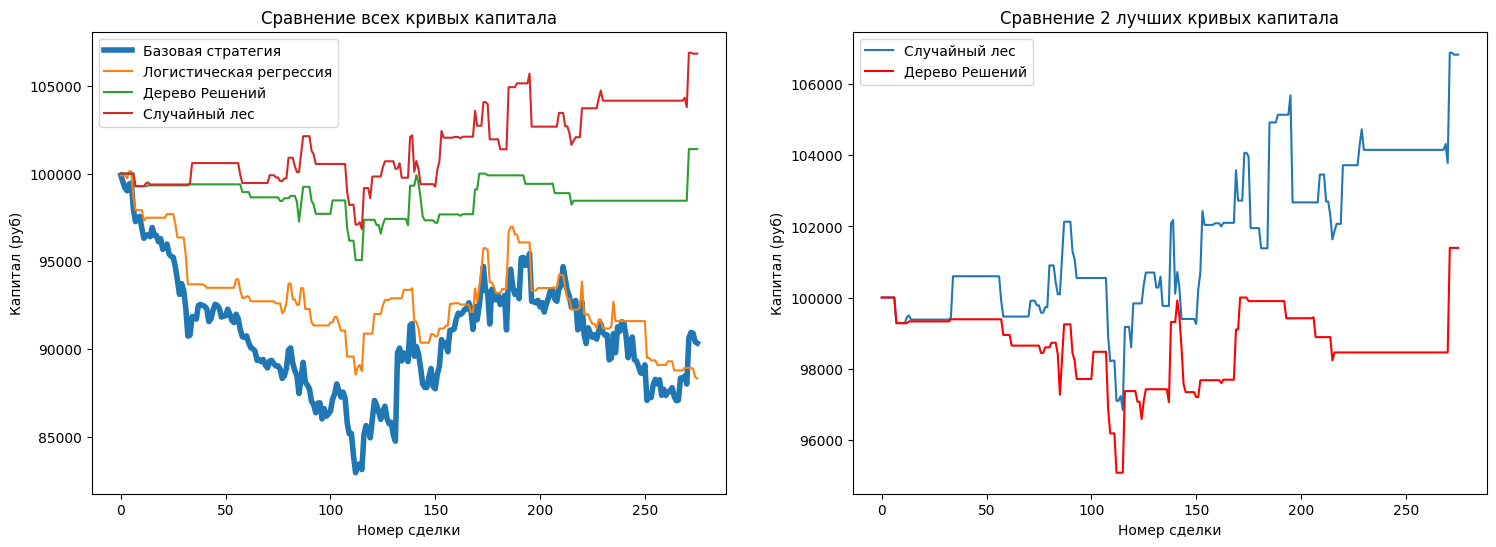

In [45]:
def final_result(data, log_list, tree_list, random_forest_list):
    """Функция для визуализации результатов стратегий

    Args:
        data (pd.DataFrame): Датафрейм со всеми признаками и целевой переменной
        log_list (np.array): Массив с результатами классификации для Логистической регрессии
        tree_list (np.array): Массив с результатами классификации для Дерева решений
        random_forest_list (np.array): Массив с результатами классификации для Случайного леса
    """
    
    
    y = np.array(data['profit_percent_net'])
    n = int(len(y) * 0.8)
    y_test = y[n:]
    
    df_result = pd.DataFrame({'profit_base' : y_test / 100, 'log' : log_list, 'dec_tree' : tree_list, 'random_forest' : random_forest_list})
    df_result['log_profit'] = df_result.apply(lambda row: row['profit_base'] if row['log']== 1 else 0, axis=1)
    df_result['dec_tree_profit'] = df_result.apply(lambda row: row['profit_base'] if row['dec_tree']== 1 else 0, axis=1)
    df_result['random_forest_profit'] = df_result.apply(lambda row: row['profit_base'] if row['random_forest']== 1 else 0, axis=1)
    dict_result = {}
    for name in ['log', 'dec_tree', 'random_forest']:
        list_result = []
        res = 100_000
        for i, profit in enumerate(df_result[f'{name}_profit']):
            if i == 0 and profit == 0:
                list_result.append(100_000)
            elif profit != 0:
                res = res*(1 + profit)
                list_result.append(res)
            elif profit == 0:
                list_result.append(res)
        dict_result[name] = list_result
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.lineplot(100_000 * np.cumprod(1 + df_result['profit_base']), ax=axes[0], linewidth=4, label='Базовая стратегия')
    sns.lineplot(dict_result['log'], ax=axes[0], label='Логистическая регрессия')
    sns.lineplot(dict_result['dec_tree'], ax=axes[0], label='Дерево Решений')
    sns.lineplot(dict_result['random_forest'], ax=axes[0], label='Случайный лес')
    axes[0].set_xlabel('Номер сделки')
    axes[0].set_ylabel('Капитал (руб)')
    axes[0].set_title('Сравнение всех кривых капитала')
    
    # Определение лучших стратегий
    max_dict = {'Базовая стратегия' : np.array(np.cumprod(1 + df_result['profit_base'])), 
                'Логистическая регрессия' : np.array(dict_result['log']), 
                'Дерево Решений' : np.array(dict_result['dec_tree']), 
                'Случайный лес' : np.array(dict_result['random_forest'])}
    max_arg1 = max(max_dict, key=lambda x: max_dict[x][-1])
    max_array1 = max_dict[max_arg1]
    del max_dict[max_arg1]
    max_arg2 = max(max_dict, key=lambda x: max_dict[x][-1])
    max_array2 = max_dict[max_arg2]

    sns.lineplot(max_array1, ax=axes[1], label=max_arg1)
    sns.lineplot(max_array2, ax=axes[1], label=max_arg2, color='red')
    axes[1].set_xlabel('Номер сделки')
    axes[1].set_ylabel('Капитал (руб)')
    axes[1].set_title('Сравнение 2 лучших кривых капитала')
            
final_result(df_ml, result_log_reg_hypper, 
             result_dec_tree_with_features, 
             result_random_forest_with_features)

Применение методов машинного обучения в данном случае выглядит как дополнительный метод защиты капитала от падения, базовая стратегия тестировалась на достаточно сложном куске истории, несмотря на затяжной падающий тренд, алгоритм смог классифицировать практически все убыточные сделки и отказался их торговать. При этом мы видим, что прибыльные сделки алгоритм классифицирует крайне плохо - метрика Recall не превосходит 0.35. 